## **Basic Assessment**

### **Data Cleaning & Preprocessing**

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("GlobalWeatherRepository.csv")

df.columns = df.columns.str.lower().str.replace(" ", "_")

df["last_updated"] = pd.to_datetime(df["last_updated"], errors="coerce")

df = df.drop_duplicates()

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[col] = df[col].clip(lower, upper)

df = df.sort_values("last_updated")

df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_pm2.5,air_quality_pm10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
186,United States of America,Washington Park,46.60,-92.96025,America/Los_Angeles,1.715849e+09,2024-05-16 01:45:00,16.1,61.0,Clear,...,6.3000,7.10000,1.0,1.0,05:26 AM,08:31 PM,01:36 PM,02:52 AM,Waxing Gibbous,55.0
40,Costa Rica,San Juan,9.97,-84.08000,America/Costa_Rica,1.715849e+09,2024-05-16 02:45:00,21.0,69.8,Fog,...,21.7000,23.30000,2.0,2.0,05:15 AM,05:51 PM,12:42 PM,12:37 AM,Waxing Gibbous,55.0
110,Mexico,Mexico City,19.43,-92.96025,America/Mexico_City,1.715849e+09,2024-05-16 02:45:00,20.8,69.4,Clear,...,35.1000,48.00000,2.0,3.0,06:01 AM,07:05 PM,01:37 PM,01:49 AM,Waxing Gibbous,55.0
52,El Salvador,San Salvador,13.71,-89.20000,America/El_Salvador,1.715849e+09,2024-05-16 02:45:00,26.0,78.8,Moderate or heavy rain with thunder,...,20.4000,28.10000,2.0,2.0,05:30 AM,06:16 PM,01:00 PM,01:02 AM,Waxing Gibbous,55.0
68,Guatemala,Guatemala City,14.62,-90.53000,America/Guatemala,1.715849e+09,2024-05-16 02:45:00,20.0,68.0,Mist,...,51.9625,86.59125,3.5,3.5,05:34 AM,06:23 PM,01:05 PM,01:09 AM,Waxing Gibbous,55.0


### **Exploratory Data Analysis (EDA)**

<class 'pandas.core.frame.DataFrame'>
Index: 40147 entries, 186 to 40146
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   country                       40147 non-null  object        
 1   location_name                 40147 non-null  object        
 2   latitude                      40147 non-null  float64       
 3   longitude                     40147 non-null  float64       
 4   timezone                      40147 non-null  object        
 5   last_updated_epoch            40147 non-null  float64       
 6   last_updated                  40146 non-null  datetime64[ns]
 7   temperature_celsius           40147 non-null  float64       
 8   temperature_fahrenheit        40147 non-null  float64       
 9   condition_text                40147 non-null  object        
 10  wind_mph                      40147 non-null  float64       
 11  wind_kph                      4

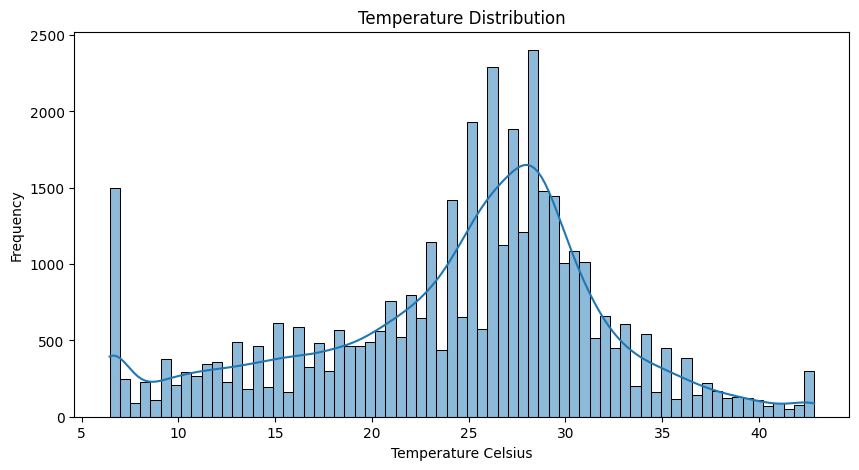

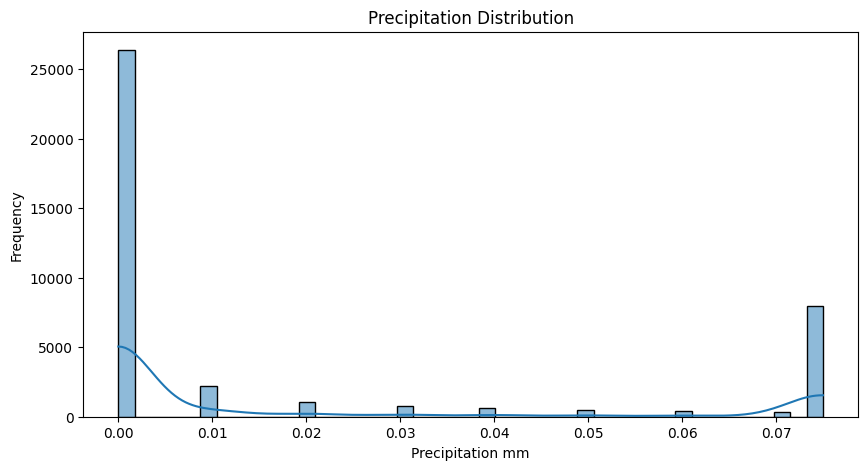

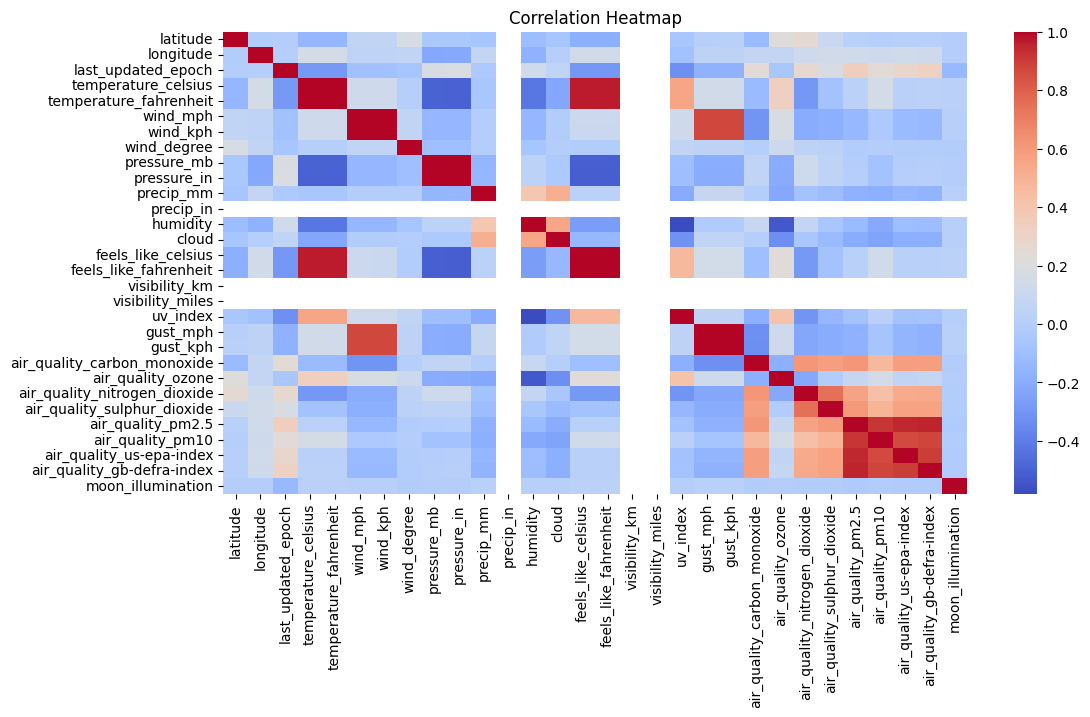

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df.info())
print(df.describe())

plt.figure(figsize=(10, 5))
sns.histplot(df["temperature_celsius"], kde=True)
plt.title("Temperature Distribution")
plt.xlabel("Temperature Celsius")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df["precip_mm"], kde=True)
plt.title("Precipitation Distribution")
plt.xlabel("Precipitation mm")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(12, 6))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

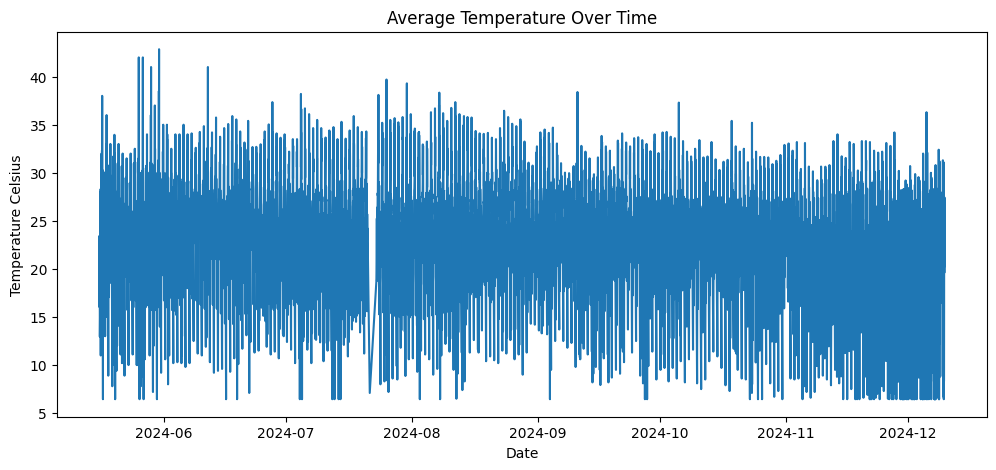

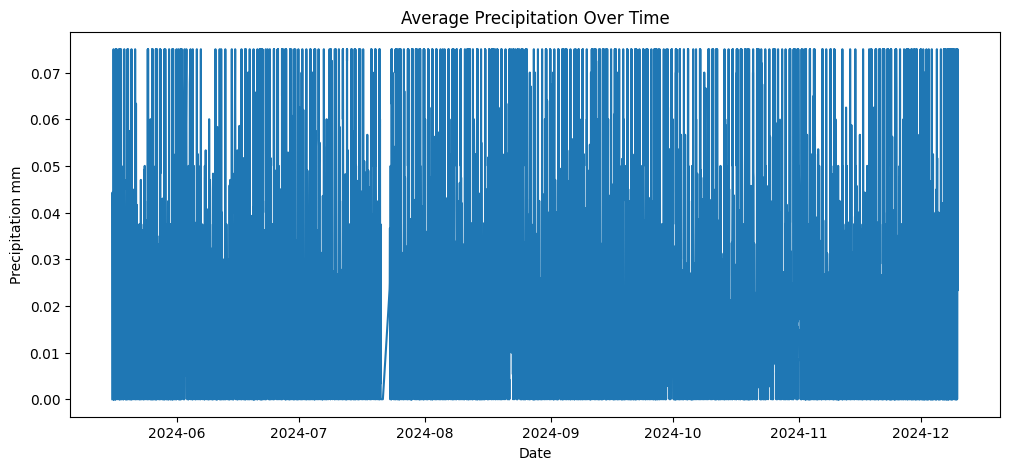

In [4]:
daily_weather = df.groupby("last_updated").agg({"temperature_celsius": "mean","precip_mm": "mean"}).reset_index()
plt.figure(figsize=(12, 5))
plt.plot(daily_weather["last_updated"], daily_weather["temperature_celsius"])
plt.title("Average Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature Celsius")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(daily_weather["last_updated"], daily_weather["precip_mm"])
plt.title("Average Precipitation Over Time")
plt.xlabel("Date")
plt.ylabel("Precipitation mm")
plt.show()

### **Model Building**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

model_data = df.copy()

model_data["year"] = model_data["last_updated"].dt.year
model_data["month"] = model_data["last_updated"].dt.month
model_data["day"] = model_data["last_updated"].dt.day
model_data["dayofyear"] = model_data["last_updated"].dt.dayofyear

features = ["humidity","pressure_mb","wind_kph","precip_mm","cloud","uv_index",
            "year","month","day","dayofyear"]

target = "temperature_celsius"

model_data = model_data.dropna(subset=features + [target])

X = model_data[features]
y = model_data[target]

split_index = int(len(model_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

rf_model = RandomForestRegressor(n_estimators=100,random_state=42)

rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Random Forest Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Random Forest Results
MAE: 4.1088147879973915
RMSE: 5.346281524318726
R2 Score: 0.621415888791248


# **Advanced Assessment**

### **Advanced EDA**

Number of anomalies: 2008


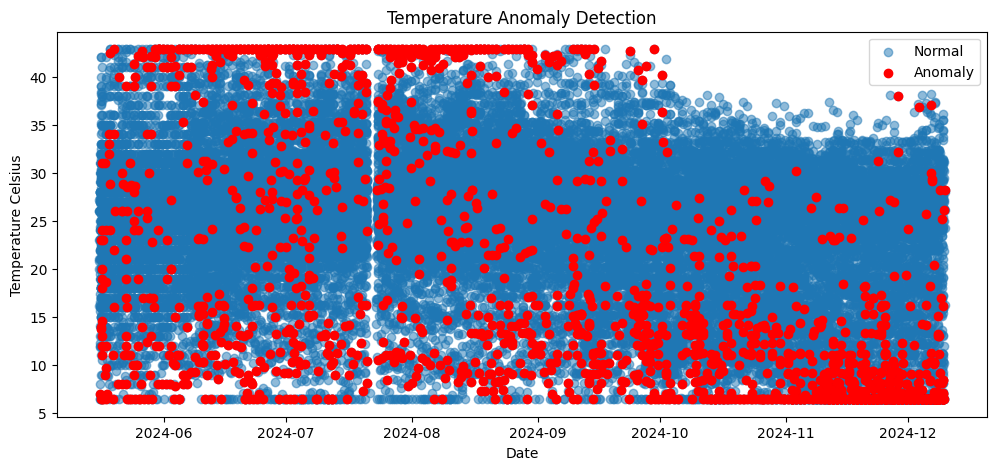

In [6]:
from sklearn.ensemble import IsolationForest

anomaly_features = ["temperature_celsius","humidity","pressure_mb","wind_kph","precip_mm"]

anomaly_df = df.dropna(subset=anomaly_features)

iso_model = IsolationForest(contamination=0.05,random_state=42)

anomaly_df["anomaly"] = iso_model.fit_predict(anomaly_df[anomaly_features])

anomalies = anomaly_df[anomaly_df["anomaly"] == -1]

print("Number of anomalies:", len(anomalies))

plt.figure(figsize=(12, 5))
plt.scatter(anomaly_df["last_updated"],anomaly_df["temperature_celsius"],
            label="Normal",alpha=0.5)
plt.scatter(anomalies["last_updated"],anomalies["temperature_celsius"],
            label="Anomaly",color="red")
plt.title("Temperature Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Temperature Celsius")
plt.legend()
plt.show()

### **Forecasting with Multiple Models**

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

models = {"Linear Regression": LinearRegression(),
          "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
          "Gradient Boosting": GradientBoostingRegressor(random_state=42)}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append({"Model": name,"MAE": mean_absolute_error(y_test, preds),
                    "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
                    "R2 Score": r2_score(y_test, preds)})

results_df = pd.DataFrame(results)
print(results_df)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  5.306696  6.542036  0.433129
1      Random Forest  4.108815  5.346282  0.621416
2  Gradient Boosting  4.351551  5.639280  0.578783


## **Ensemble Model**

In [8]:
linear_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
gb_model = GradientBoostingRegressor(random_state=42)

linear_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

pred_linear = linear_model.predict(X_test)
pred_rf = rf_model.predict(X_test)
pred_gb = gb_model.predict(X_test)

ensemble_predictions = (pred_linear + pred_rf + pred_gb) / 3

ensemble_mae = mean_absolute_error(y_test, ensemble_predictions)
ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_predictions))
ensemble_r2 = r2_score(y_test, ensemble_predictions)

print("Ensemble Model Results")
print("MAE:", ensemble_mae)
print("RMSE:", ensemble_rmse)
print("R2 Score:", ensemble_r2)

Ensemble Model Results
MAE: 4.439541463065218
RMSE: 5.60381051250882
R2 Score: 0.5840648550541534


## **Unique Analyses**

### **Climate Analysis**

                  country  temperature_celsius   humidity  precip_mm
158         Saudi Arabien            42.850000   7.000000   0.000000
113              Marrocos            40.300000  14.000000   0.000000
189          Turkménistan            37.800000  11.000000   0.000000
157          Saudi Arabia            37.554390  12.229268   0.000000
93                 Kuwait            36.829710  22.082126   0.001208
146                 Qatar            36.323058  41.029126   0.000000
80                   Iraq            36.234541  18.086957   0.000000
194  United Arab Emirates            35.110437  48.708738   0.000000
47               Djibouti            34.322439  51.512195   0.005756
12                Bahrain            34.017874  50.043478   0.000000


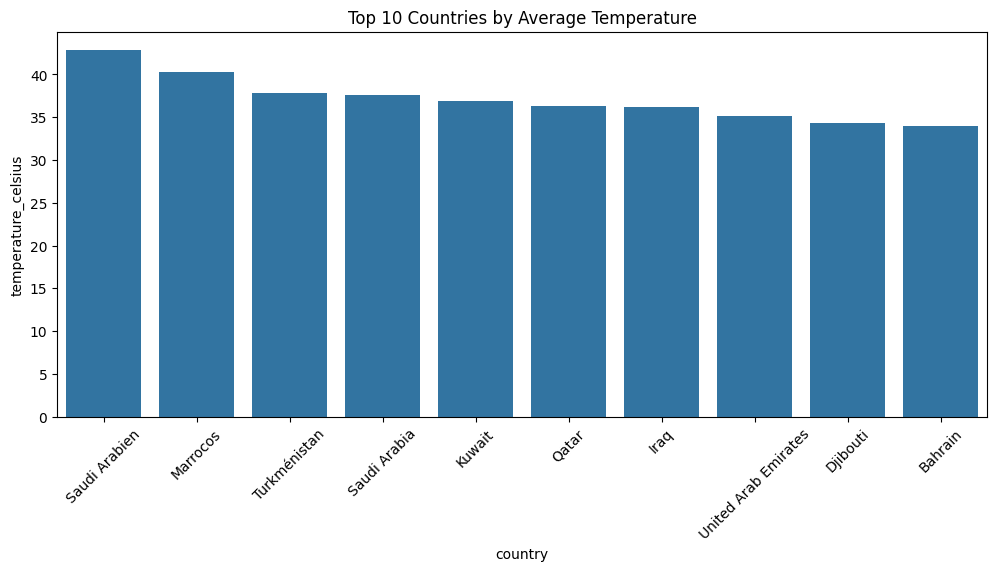

In [9]:
country_climate = df.groupby("country").agg({"temperature_celsius": "mean",
                                             "humidity": "mean",
                                             "precip_mm": "mean"}).reset_index()

top_hot_countries = country_climate.sort_values("temperature_celsius",ascending=False).head(10)

print(top_hot_countries)
plt.figure(figsize=(12, 5))
sns.barplot(data=top_hot_countries,x="country",y="temperature_celsius")
plt.xticks(rotation=45)
plt.title("Top 10 Countries by Average Temperature")
plt.show()

### **Environmental Impact**

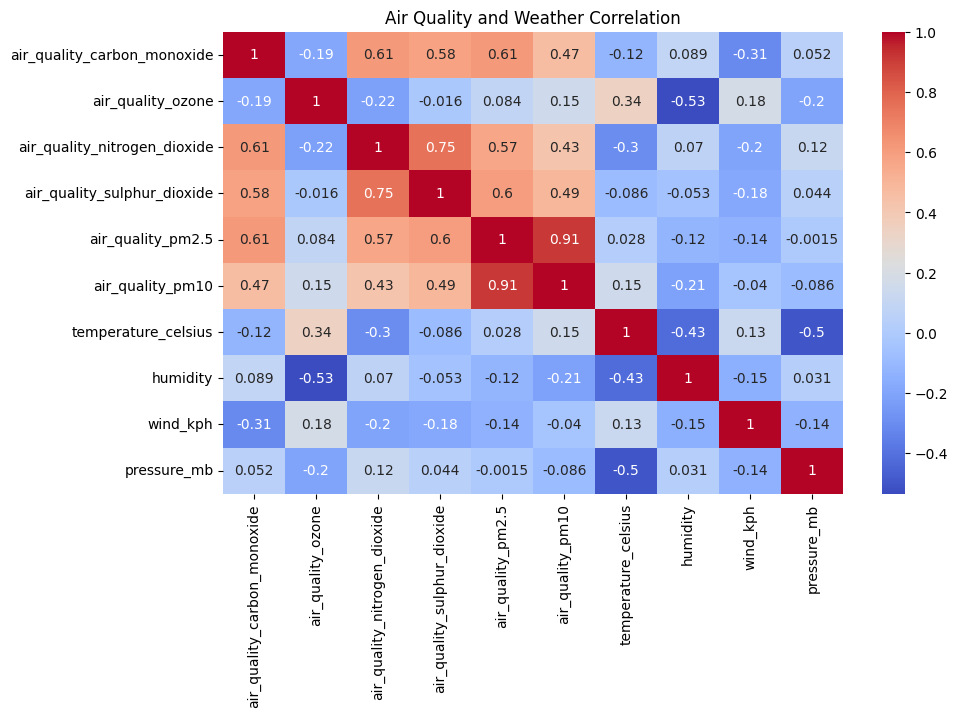

In [10]:
air_quality_cols = ["air_quality_carbon_monoxide","air_quality_ozone",
                    "air_quality_nitrogen_dioxide","air_quality_sulphur_dioxide",
                    "air_quality_pm2.5","air_quality_pm10"]

available_air_cols = [col for col in air_quality_cols if col in df.columns]
env_cols = available_air_cols + ["temperature_celsius","humidity","wind_kph","pressure_mb"]
env_corr = df[env_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(env_corr, annot=True, cmap="coolwarm")
plt.title("Air Quality and Weather Correlation")
plt.show()

### **Feature Importance**

       Feature  Importance
5     uv_index    0.519712
1  pressure_mb    0.203845
0     humidity    0.078694
9    dayofyear    0.066949
2     wind_kph    0.037700
4        cloud    0.036136
3    precip_mm    0.030281
8          day    0.022250
7        month    0.004433
6         year    0.000000


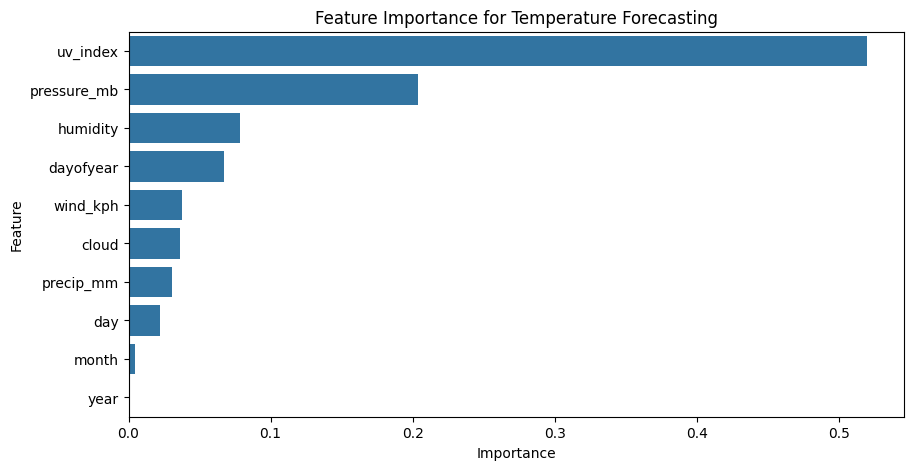

In [11]:
importance_df = pd.DataFrame({"Feature": features,"Importance": rf_model.feature_importances_
                              }).sort_values("Importance", ascending=False)

print(importance_df)
plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df,x="Importance",y="Feature")
plt.title("Feature Importance for Temperature Forecasting")
plt.show()

### **Spatial Analysis**

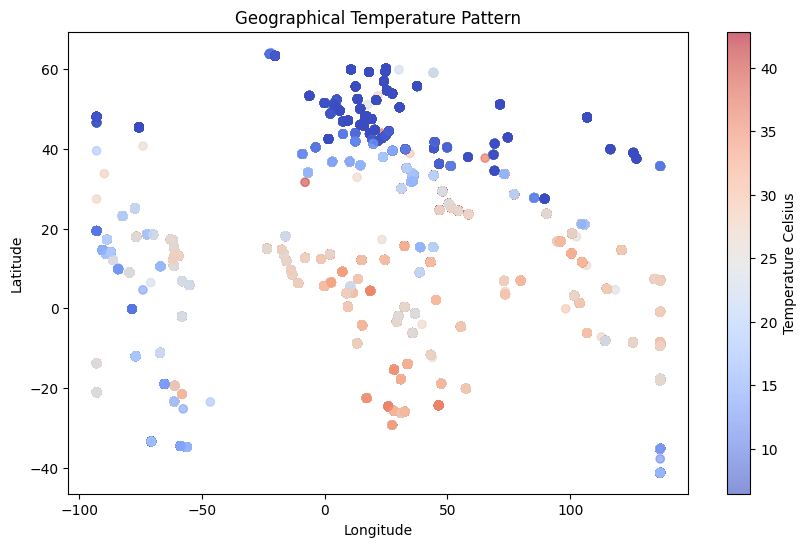

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(df["longitude"],df["latitude"],c=df["temperature_celsius"],
            cmap="coolwarm",alpha=0.6)

plt.colorbar(label="Temperature Celsius")
plt.title("Geographical Temperature Pattern")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### **Geographical Patterns**

In [13]:
geo_summary = df.groupby(["country", "location_name"]).agg({"temperature_celsius": "mean",
                                                            "humidity": "mean",
                                                            "precip_mm": "mean",
                                                            "wind_kph": "mean"
                                                            }).reset_index()
print(geo_summary.head(20))

                country      location_name  temperature_celsius   humidity  \
0           Afghanistan              Kabul            24.403623  22.700483   
1               Albania             Tirana            26.483816  48.342995   
2               Algeria            Algiers            26.356311  54.849515   
3               Andorra   Andorra La Vella            15.768841  55.971014   
4                Angola             Luanda            26.170531  70.483092   
5   Antigua and Barbuda       Saint John's            28.207843  77.661765   
6             Argentina       Buenos Aires            12.899029  81.427184   
7               Armenia            Yerevan            24.638406  32.526570   
8             Australia           Canberra            10.476942  78.927184   
9             Australia          Melbourne            11.600000  54.000000   
10              Austria             Vienna            19.945146  58.762136   
11           Azerbaijan               Baku            23.833010 